<a href="https://colab.research.google.com/github/sknadler/mlb-pitcher-stamina/blob/main/MLB_Pitcher_Stamina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting MLB Pitcher Stamina with Game-Level Stuff Data**<br>
Samantha Nadler

https://github.com/sknadler/mlb-pitcher-stamina

A decades-long trend within Major League Baseball (MLB) is that starting pitchers are averaging fewer pitches per game started. In a sport where pitchers were celebrated for pitching a complete nine-inning game, a steady decline in innings pitched has left starting pitchers averaging 5.0 to 6.0 innings pitched per game started. Per FanGraphs' [Ben Clemens](https://blogs.fangraphs.com/a-deeper-dive-into-pitcher-usage-trends/), in just eight seasons, between 2016 and 2024 the average number of innings pitched per game started dropped from just over 6.0 innings to just over 5.0 innings.

A plausible cause for the decline in length of pitcher starts could be the increase in release speed for high-speed pitches. [Justin Choi](https://blogs.fangraphs.com/breaking-down-baseballs-early-velocity-surge/) of FanGraphs determined that while starting pitchers were averaging four-seam fastballs approximately 1.5 miles per hour slower than relief pitchers in the 2008 season (i.e. approximately 91 mph vs. 92.5 mph for starters and relievers, respectively), the release speeds of the two groups converged to approximately 93 mph during the 2022 season. With starting pitchers possibly copying the pitch mechanics of relievers, late-game pitchers whose shorter stamina allows them to throw higher-speed pitches, they are ultimately lowering their own stamina and stuff in their pitch arsenal.

Stuff refers to the physical qualities of all pitches in a pitcher's arsenal. Qualities that dictate a pitcher's stuff include pitch speed, spin rate, and any horizontal or vertical pitch movement. This project aims to model the number of pitches thrown by a pitcher in a game using averaged values of stuff measurements defined by Baseball Savant for each pitch type in their arsenal. Statcast data is taken from the [`pybaseball`](https://github.com/jldbc/pybaseball) package and will be aggregated into two datasets, one at the game level and one at the pitch level. Basic linear regression models will be built on the game-level data while pitch-level data will be used to visualize in-game trends of a pitcher's velocity for the top used pitches in a given game.

In [ ]:
# IGNORE WARNINGS

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# INSTALL PYBASEBALL

! pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00


In [ ]:
# IMPORT PYTHON PACKAGES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import pybaseball

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# LOAD THE 2025 STATCAST DATASET

df = pybaseball.statcast(start_dt = '2025-03-01', end_dt = '2025-11-01')

This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 232/232 [03:25<00:00,  1.13it/s]


**Data Cleaning and Engineering**

The data used in this project comes from the `pybaseball` package, which pulls requested data from various online baseball data sources, including Statcast. After calling the `pybaseball.statcast` function in the above cell, the package returns a pitch-level dataset of all pitches thrown in the given time window and contains data collected using MLB's Statcast data tracking system. Included in the pitch-level dataset is data regarding pitch measurements, current game conditions, and hit ball measurements.

The following steps were taken to engineer the dataset so that it mirrors [this Baseball Savant dataset](https://baseballsavant.mlb.com/leaderboard/custom?year=2025&type=pitcher&filter=&min=q&selections=n_ff_formatted%2Cff_avg_speed%2Cff_avg_spin%2Cff_avg_break_x%2Cff_avg_break_z_induced%2Cff_avg_break%2Cn_sl_formatted%2Csl_avg_speed%2Csl_avg_spin%2Csl_avg_break_x%2Csl_avg_break_z_induced%2Csl_avg_break%2Cn_ch_formatted%2Cch_avg_speed%2Cch_avg_spin%2Cch_avg_break_x%2Cch_avg_break_z_induced%2Cch_avg_break%2Cn_cu_formatted%2Ccu_avg_speed%2Ccu_avg_spin%2Ccu_avg_break_x%2Ccu_avg_break_z_induced%2Ccu_avg_break%2Cn_si_formatted%2Csi_avg_speed%2Csi_avg_spin%2Csi_avg_break_x%2Csi_avg_break_z_induced%2Csi_avg_break%2Cn_fc_formatted%2Cfc_avg_speed%2Cfc_avg_spin%2Cfc_avg_break_x%2Cfc_avg_break_z_induced%2Cfc_avg_break%2Cn_fs_formatted%2Cfs_avg_speed%2Cfs_avg_spin%2Cfs_avg_break_x%2Cfs_avg_break_z_induced%2Cfs_avg_break%2Cn_kn_formatted%2Ckn_avg_speed%2Ckn_avg_spin%2Ckn_avg_break_x%2Ckn_avg_break_z_induced%2Ckn_avg_break%2Cn_st_formatted%2Cst_avg_speed%2Cst_avg_spin%2Cst_avg_break_x%2Cst_avg_break_z_induced%2Cst_avg_break%2Cn_sv_formatted%2Csv_avg_speed%2Csv_avg_spin%2Csv_avg_break_x%2Csv_avg_break_z_induced%2Csv_avg_break%2Cn_fo_formatted%2Cfo_avg_speed%2Cfo_avg_spin%2Cfo_avg_break_x%2Cfo_avg_break_z_induced%2Cfo_avg_break%2Cn_sc_formatted%2Csc_avg_speed%2Csc_avg_spin%2Csc_avg_break_x%2Csc_avg_break_z_induced%2Csc_avg_break&chart=false&x=n_ff_formatted&y=n_ff_formatted&r=no&chartType=beeswarm&sort=1&sortDir=asc) of season-level pitch data. The data used for this project is engineered at a game level but mirrors the Baseball Savant dataset.

- Any non-regular season games were filtered out.
- Any non-qualified pitcher was filtered out (i.e. pitchers who pitched less than 160.0 innings or 486 outs).
- Features including Induced Vertical Break, total break using Euclidean distance, distance from home plate in inches, and pitch count were engineered.
- Means, ranges, and pitch speed decay were generated for each pitch type by game.
- A feature for pitch usage percentage was generated by dividing the number of pitches thrown per type over a pitcher's total pitch count for a game. (To prevent data leakage, only the pitch percentage, not the number of pitches thrown per pitch type, was used in the final dataset.)
- A "stress rate" feature was engineered that divides hits, walks, and hit by pitches over the total number of batters.
- The dataset was flattened and a total pitch count feature was generated.

In [ ]:
# DATA CLEANING AND ENGINEERING
# (Part I: Create df_pitch_level for data exploration)

# (1) Filter out any non-regular season games

df = df[df['game_type'] == 'R']

# (2) Filter out non-qualified pitchers (must have pitched >= 162 innings or 486 outs)

df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number']).reset_index(drop=True)
df['is_last_pitch'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_number'].transform('max') == df['pitch_number']
df_plays = df[df['is_last_pitch']].copy().reset_index(drop=True)
df_plays['next_outs'] = df_plays.groupby(['game_pk', 'inning', 'inning_topbot'])['outs_when_up'].shift(-1)
df_plays['outs_recorded'] = np.where(df_plays['next_outs'].isna(), 3 - df_plays['outs_when_up'], df_plays['next_outs'] - df_plays['outs_when_up'])
pitcher_outs = df_plays.groupby('player_name')['outs_recorded'].sum()
qualified_pitchers = pitcher_outs[pitcher_outs >= 486].index

df_qual = df[df['player_name'].isin(qualified_pitchers)]
df_qual = df_qual.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

# (3) Add the pitch-level data (only keep data of pitch types with available averages on Baseball Savant)
#
#     Features engineered:
#     - ivb: Induced Vertical Break, a measure of vertical movement solely from spin (Calcuation: pfx_z * 12)
#     - total_break: A Euclidean distance of horizontal break and IVB
#     - plate_x_in: A measure of horizontal distance from home plate of a pitch, from the catcher's perspective (Calculation: plate_x * 12)
#     - plate_z_in: A measure of vertical distance from home plate of a pitch, from the catcher's perspective (Calculation: plate_z * 12)
#     - no_pitches: Keeps track of the current pitch number thrown by a pitcher

df_qual['pfx_z_in'] = df_qual['pfx_z'] * 12
df_qual['total_break'] = np.sqrt(df_qual['pfx_x'] ** 2 + df_qual['pfx_z_in'] ** 2)
df_qual['plate_x_in'] = df_qual['plate_x'] * 12
df_qual['plate_z_in'] = df_qual['plate_z'] * 12
df_qual['no_pitches'] = df_qual.groupby(['player_name', 'game_pk']).cumcount() + 1

pitches_qual = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC', 'FS', 'ST', 'SV']
df_final = df_qual[df_qual['pitch_type'].isin(pitches_qual)][['player_name', 'game_date', 'game_pk', 'pitch_type', 'release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z_in', 'total_break', 'plate_x_in', 'plate_z_in', 'no_pitches']].copy()
df_final = df_final.dropna(subset=['release_speed'])

In [ ]:
# DATA CLEANING AND ENGINEERING
# (Part II: Create df_game_by_game for data modeling)

# (4) Aggregate mean and range of all following columns and delta of release_speed
#
#     Features engineered:
#     - release_speed_decay_rate: Calculates the rate of change in pitch speed over time

df_final = df_final.sort_values(['game_pk', 'no_pitches'])
cols = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z_in', 'total_break', 'plate_x_in', 'plate_z_in']

def calc_velocity_decay(x):
    if len(x) < 2: return 0

    return (x.iloc[-1] - x.iloc[0]) / (len(x) - 1)

agg_dict = {col: ['mean', np.ptp] for col in cols}
agg_dict['release_speed'].append(calc_velocity_decay)
agg_dict['no_pitches'] = 'count'

df_game_by_game = df_final.groupby(['player_name', 'game_date', 'game_pk', 'pitch_type']).agg(agg_dict)

def rename_col(col_tuple):
    col, func = col_tuple
    if func == 'ptp': return f"{col}_range"
    if func == 'count': return f"{col}_count"
    if func == 'calc_velocity_decay': return f"{col}_decay_rate"

    return f"{col}_{func}"

df_game_by_game.columns = [rename_col(c) for c in df_game_by_game.columns]
df_game_by_game = df_game_by_game.reset_index()


# (5) Create a feature pct_pitches that calculates pitch mix of each pitch thrown in a game

total_pitches_per_game = df_game_by_game.groupby(['player_name', 'game_date', 'game_pk'])['no_pitches_count'].transform('sum')
df_game_by_game['pct_pitches'] = df_game_by_game['no_pitches_count'] / total_pitches_per_game


# (6) Extract game context (e.g. hits and walks, pitcher stress)

game_events = df_qual.groupby(['player_name', 'game_date', 'game_pk']).agg(
    batters_faced = ('at_bat_number', 'nunique'),
    hits = ('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    walks = ('events', lambda x: x.isin(['walk', 'hit_by_pitch']).sum())
).reset_index()

game_events['stress_rate'] = (game_events['hits'] + game_events['walks']) / game_events['batters_faced']


# (7) Flatten the dataset so each row has all data from all pitch types of a single game

df_game_by_game = df_game_by_game.pivot(index = ['player_name', 'game_date', 'game_pk'],columns = 'pitch_type')
df_game_by_game.columns = [f"{pitch_type}_{metric}" for metric, pitch_type in df_game_by_game.columns]
df_game_by_game = df_game_by_game.reset_index()


# (8) Create a label for the total number of pitches thrown in a game

count_cols = [col for col in df_game_by_game.columns if 'no_pitches' in col]
df_game_by_game['total_no_pitches'] = df_game_by_game[count_cols].sum(axis = 1)

**Data Exploration**

We use the `df_pitch_level` dataset to perform exploratory analysis and observe trends in decays in a pitcher's velocity. The following function creates a pair of visualizations that show several features that contribute to late-game fatigue. For example, the visualizations below show Paul Skenes' pitcher fatigue during Opening Day 2025 (March 27, 2025). Per [MLB.com](https://www.mlb.com/player/paul-skenes-694973?stats=gamelogs-r-pitching-mlb&year=2025), Skenes threw 94 pitches over 5.1 innings pitched, giving up three hits.

The first visualization is a series of four scatterplots that measure pitch number in the game against the release speed of a given pitch. The data is filtered out to determine a pitcher's top four used pitches in a game, and plots are scattered against a regression line with a labeled slope, indicating the average dropoff of pitch speed as the game progresses. All four of Skenes's pitches have a negative slope, indicating the hypothesis that eventually a pitcher is unable to sustain a consistent release speed. The second visualization is a pie chart showing the pitcher's pitch mix for the selected game.

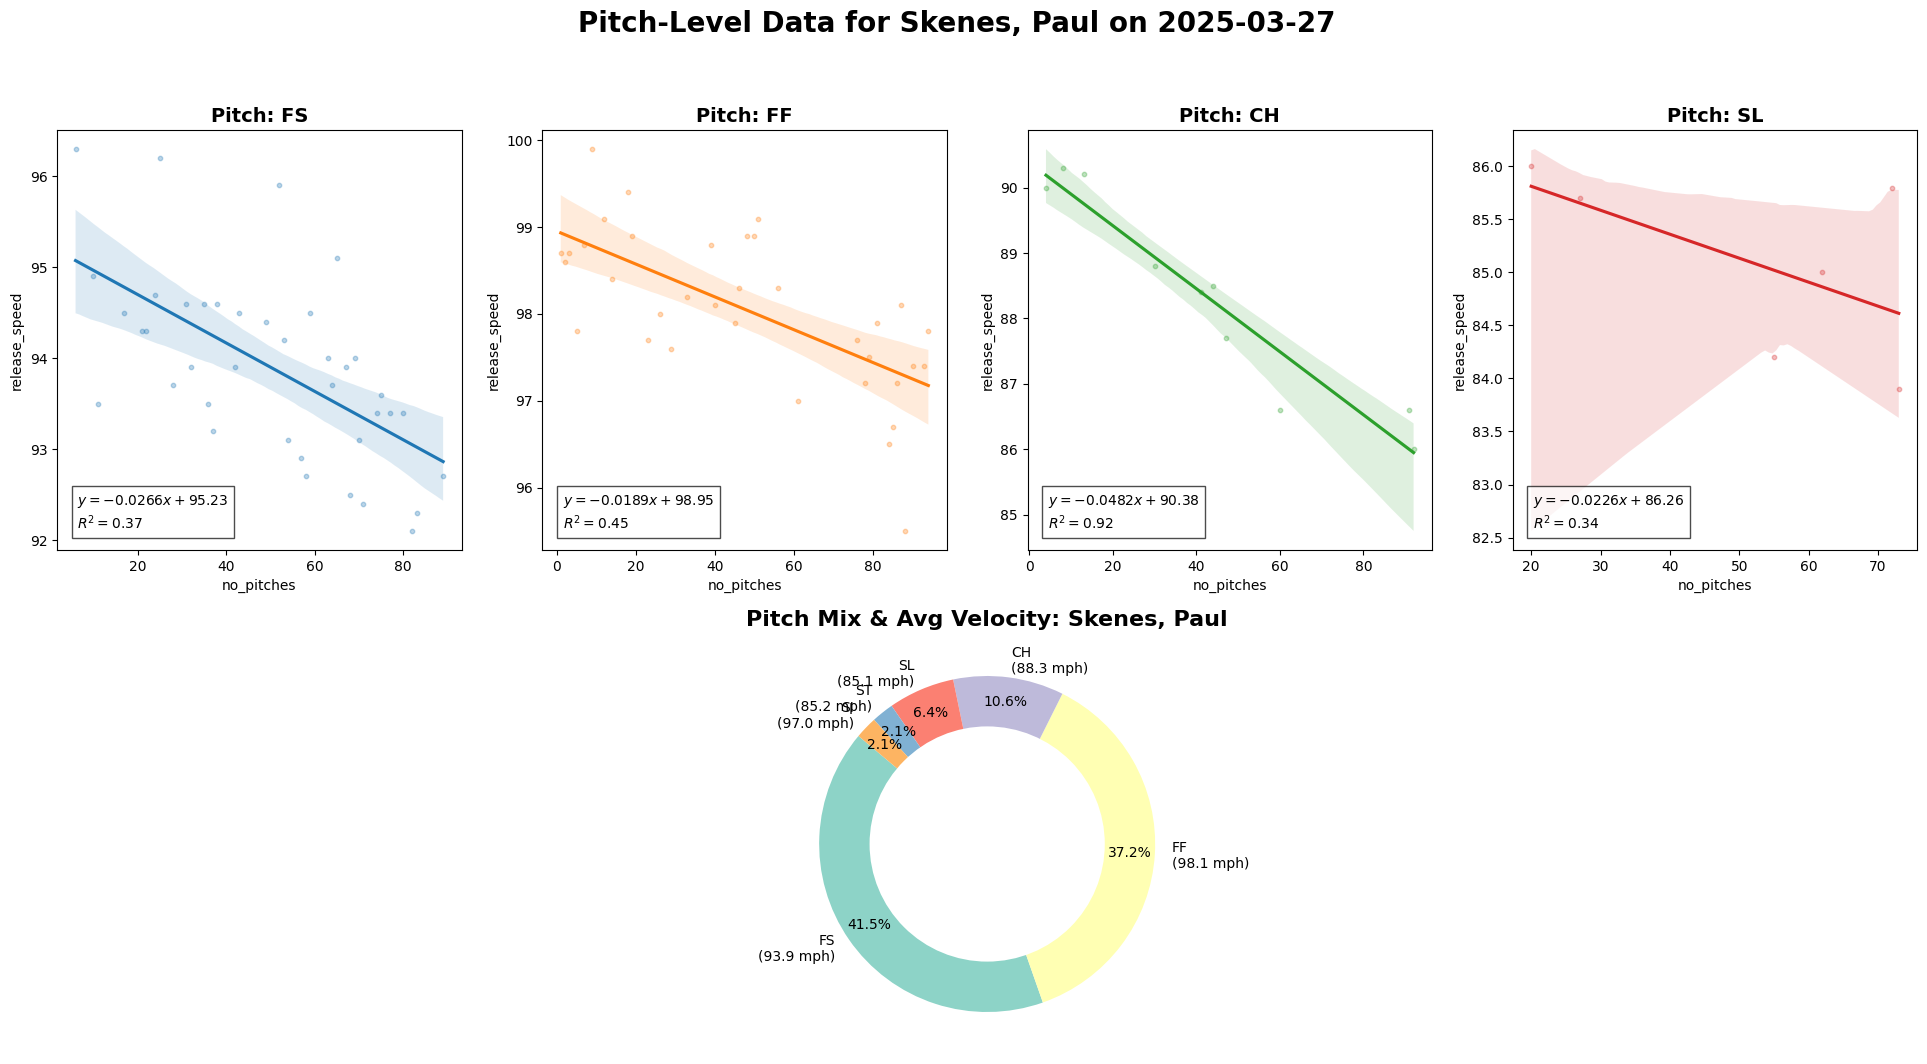

In [ ]:
# DATA EXPLORATION
# (Using df_pitch_level)

def visualize_pitcher_fatigue(pitcher_name, date):
    df_p = df_final[df_final['player_name'] == pitcher_name].copy()
    df_p = df_p[df_p['game_date'] == date]

    top_pitches = df_p['pitch_type'].value_counts().head(4).index.tolist()

    fig = plt.figure(figsize=(24, 12))
    gs = fig.add_gridspec(2, 4)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # (1) Scatter plots of pitch number vs. velocity for a pitcher's top four used pitches in a game

    for i, p_type in enumerate(top_pitches):
        ax = fig.add_subplot(gs[0, i])
        plot_data = df_p[df_p['pitch_type'] == p_type]

        if not plot_data.empty:
            sns.regplot(x = 'no_pitches', y = 'release_speed', data = plot_data, ax = ax, color = colors[i], scatter_kws = {'alpha': 0.3, 's': 10})
            slope, intercept, r_val, p_val, std_err = stats.linregress(plot_data['no_pitches'], plot_data['release_speed'])
            ax.set_title(f"Pitch: {p_type}", fontsize=14, fontweight = 'bold')
            ax.text(0.05, 0.05, f"$y = {slope:.4f}x + {intercept:.2f}$\n$R^2 = {r_val**2:.2f}$", transform = ax.transAxes, bbox = dict(facecolor = 'white', alpha = 0.7))

    # (2) Pie chart of pitch mix for a game with average pitch velocities

    ax_pie = fig.add_subplot(gs[1, :])
    pitch_counts = df_p['pitch_type'].value_counts()
    avg_velos = df_p.groupby('pitch_type')['release_speed'].mean()
    pie_labels = [f"{pt}\n({avg_velos[pt]:.1f} mph)" for pt in pitch_counts.index]

    ax_pie.pie(pitch_counts, labels = pie_labels, autopct = '%1.1f%%', startangle = 140, colors = sns.color_palette("Set3"), pctdistance = 0.85)
    centre_circle = plt.Circle((0,0), 0.70, fc = 'white')
    ax_pie.add_artist(centre_circle)
    ax_pie.set_title(f"Pitch Mix & Avg Velocity: {pitcher_name}", fontsize = 16, fontweight = 'bold')

    plt.suptitle(f"Pitch-Level Data for {pitcher_name} on {date}", fontsize = 20, fontweight = 'bold')
    plt.show()


visualize_pitcher_fatigue('Skenes, Paul', '2025-03-27')

**Data Modeling**

Before data modeling, the following steps had to be taken to ensure the data was properly formatted to the liking of the linear models:

- Missing pitch usage percentage was updated to 0.
- Missing pitch stuff data in a pitcher's arsenal was updated to the mean of the feature.
- All other features were updated to the league-wide mean.

All features were updated so that the linear models were fit on weighted and scaled data. Stuff data was multiplied by the pitch percentage for a more stratified representation of a pitcher's stuff for a given game. The number of pitches was log-transformed and four Lasso models were fit to the following subsets of the transformed data.

- **Lasso A** was fit to data excluding catcher-observed data of all pitch types thrown in a game.
- **Lasso B** was fit to data excluding catcher-observed data of the top four pitch types thrown in a game.
- **Lasso C** was fit to all data of all pitch types thrown in a game (the full dataset).
- **Lasso D** was fit to all data of the top four pitch types thrown in a game.

In [ ]:
# DATA MODELING
# (Using df_game_by_game)

# (1) Handle missing non-applicable values (i.e. NaN values recorded because a pitcher did not throw that pitch in a particular game)
#     Start with pitch mix and number of pitches thrown (easiest missing values to impute - all NaN will be replaced with 0)

pct_cols = [col for col in df_game_by_game.columns if 'pct_pitches' in col]
no_cols = [col for col in df_game_by_game.columns if 'no_pitches_count' in col]
cols = pct_cols + no_cols
df_game_by_game[cols] = df_game_by_game[cols].fillna(0)


# Impute pitches thrown by a pitcher but not thrown in a game with their seasonal mean (i.e. Andrew Abbott threw a cutter in his first two appearances but not in the next three)

metrics = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z_in', 'total_break', 'plate_x_in', 'plate_z_in']
target_cols = [col for col in df_game_by_game.columns if any(m in col for m in metrics)]
df_game_by_game[target_cols] = df_game_by_game[target_cols].astype(float)

for col in target_cols:
    df_game_by_game[col] = df_game_by_game.groupby('player_name')[col].transform(lambda x: x.fillna(x.mean()))


# Fill rest of null values with league-wide average

for col in target_cols:
    league_avg = df_game_by_game[col].mean()
    df_game_by_game[col] = df_game_by_game[col].fillna(league_avg)

In [ ]:
# DATA MODELING

# (2) Transform the data so that it contains weighted data (model-ready data)

df_weighted = df_game_by_game.copy()

for pt in pitches_qual:
    usage_col = f"{pt}_pct_pitches"

    if usage_col in df_weighted.columns:
        pt_metrics = [c for c in target_cols if c.startswith(f"{pt}_")]

        for col in pt_metrics:
            df_weighted[col] = df_weighted[col].fillna(0) * df_weighted[usage_col]


# (3) Create a pitch zone flag (determines if pitch control affects a pitcher's number of pitches thrown)

df_final['is_zone'] = df_final['plate_x_in'].abs().le(10) & df_final['plate_z_in'].between(18, 42)
pitch_zone_stats = df_final.groupby(['player_name', 'game_date', 'game_pk', 'pitch_type'])['is_zone'].mean().reset_index()
pitch_zone_stats.rename(columns = {'is_zone': 'zone_pct'}, inplace=True)

pitch_zone_pivoted = pitch_zone_stats.pivot(index = ['player_name', 'game_date', 'game_pk'], columns = 'pitch_type', values = 'zone_pct')
pitch_zone_pivoted.columns = [f"{pt}_zone_pct" for pt in pitch_zone_pivoted.columns]
pitch_zone_pivoted = pitch_zone_pivoted.reset_index().fillna(0)

df_weighted = df_weighted.merge(game_events, on = ['player_name', 'game_date', 'game_pk'])
df_weighted = df_weighted.merge(pitch_zone_pivoted, on = ['player_name', 'game_date', 'game_pk'])


# (4) Create variables for pitcher rest between games

df_weighted = df_weighted.sort_values(['player_name', 'game_date'])
df_weighted['days_rest'] = df_weighted.groupby('player_name')['game_date'].diff().dt.days.fillna(5)
df_weighted['prev_leash'] = df_weighted.groupby('player_name')['total_no_pitches'].transform(lambda x: x.rolling(3, min_periods = 1).mean().shift(1)).fillna(75)

In [ ]:
# DATA MODELING

# (5) Base linear model trained on all data

leakage_cols = [c for c in df_weighted.columns if 'no_pitches_count' in c]

X = df_weighted.drop(columns=['player_name', 'game_date', 'game_pk', 'total_no_pitches'] + leakage_cols)
X_scaled_array = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns)
y = df_weighted['total_no_pitches']
y_log = np.log(y)

X_train_full, X_val_full, y_train, y_val = train_test_split(X_scaled, y_log, test_size = 0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_full, y_train)
lr.score(X_val_full, y_val)

0.6767376205181184

In [ ]:
# DATA MODELING

# (6) Fit LASSO regression models on four subsets of the data and calculate R^2
#
#     Data used:
#     (a) Pitch mix and pitcher-perspective data of all pitchs types thrown in a game
#     (b) Pitch mix and pitcher-perspective data of the top 4 pitch types thrown in a game
#     (c) All data of all pitch types thrown in a game
#     (d) All data of the top 4 pitch types thrown in a game

lasso_a_cols = [c for c in X.columns if 'plate' not in c and 'zone' not in c]

X_train_a = X_train_full[lasso_a_cols]
X_val_a = X_val_full[lasso_a_cols]

lasso_a = LassoCV(cv = 10)
lasso_a.fit(X_train_a, y_train)
lasso_a.score(X_val_a, y_val)

0.7088387205517521

In [ ]:
def get_ranked_arsenal_features(df_input, n = 4):
    usage_cols = [c for c in df_input.columns if 'pct_pitches' in c]
    all_metrics = []

    for c in df_input.columns:
        if '_' in c and 'plate' not in c and 'zone' not in c:
            parts = c.split('_', 1)
            metric_name = parts[1]
            if metric_name not in all_metrics:
                all_metrics.append(metric_name)

    top_n_indices = np.argsort(-df_input[usage_cols].values, axis=1)[:, :n]
    ranked_data = {}

    for i in range(1, n + 1):
        for m in all_metrics:
            ranked_data[f'Rank{i}_{m}'] = np.zeros(len(df_input))

    for row_idx in range(len(df_input)):
        for rank_pos in range(n):
            col_idx = top_n_indices[row_idx, rank_pos]
            pitch_prefix = usage_cols[col_idx].split('_')[0]

            for m in all_metrics:
                source_col = f"{pitch_prefix}_{m}"
                if source_col in df_input.columns:
                    val = df_input.iloc[row_idx][source_col]
                    ranked_data[f'Rank{rank_pos+1}_{m}'][row_idx] = val

    return pd.DataFrame(ranked_data, index=df_input.index)

X_train_b_ranked = get_ranked_arsenal_features(X_train_full, n=4)
X_val_b_ranked = get_ranked_arsenal_features(X_val_full, n=4)

lasso_b = LassoCV(cv = 10)
lasso_b.fit(X_train_b_ranked, y_train)
lasso_b.score(X_val_b_ranked, y_val)

0.3741866437116821

In [ ]:
lasso_c = LassoCV(cv = 10)
lasso_c.fit(X_train_full, y_train)
lasso_c.score(X_val_full, y_val)

0.7683699616885463

In [ ]:
def get_ranked_all_data(df_input, n = 4):
    usage_cols = [c for c in df_input.columns if 'pct_pitches' in c]
    all_metrics = []

    for c in df_input.columns:
        if '_' in c:
            parts = c.split('_', 1)
            metric_name = parts[1]

            if metric_name not in all_metrics:
                all_metrics.append(metric_name)

    top_n_indices = np.argsort(-df_input[usage_cols].values, axis=1)[:, :n]
    ranked_data = {}

    for i in range(1, n + 1):
        for m in all_metrics:
            ranked_data[f'Rank{i}_{m}'] = np.zeros(len(df_input))

    for row_idx in range(len(df_input)):
        for rank_pos in range(n):
            col_idx = top_n_indices[row_idx, rank_pos]
            pitch_prefix = usage_cols[col_idx].split('_')[0]

            for m in all_metrics:
                source_col = f"{pitch_prefix}_{m}"
                if source_col in df_input.columns:
                    ranked_data[f'Rank{rank_pos+1}_{m}'][row_idx] = df_input.iloc[row_idx][source_col]

    return pd.DataFrame(ranked_data, index = df_input.index)

X_train_d_ranked = get_ranked_all_data(X_train_full, n = 4)
X_val_d_ranked = get_ranked_all_data(X_val_full, n = 4)

lasso_d = LassoCV(cv = 10)
lasso_d.fit(X_train_d_ranked, y_train)
lasso_d.score(X_val_d_ranked, y_val)

0.48715248880001893

In [ ]:
# DATA MODELING

# (7) Calculate RMSE of each model

from sklearn.metrics import mean_squared_error

y_pred_lr = lr.predict(X_val_full)
y_pred_a = lasso_a.predict(X_val_a)
y_pred_b = lasso_b.predict(X_val_b_ranked)
y_pred_c = lasso_c.predict(X_val_full)
y_pred_d = lasso_d.predict(X_val_d_ranked)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
rmse_a = np.sqrt(mean_squared_error(y_val, y_pred_a))
rmse_b = np.sqrt(mean_squared_error(y_val, y_pred_b))
rmse_c = np.sqrt(mean_squared_error(y_val, y_pred_c))
rmse_d = np.sqrt(mean_squared_error(y_val, y_pred_d))

print('Linear regression RMSE:', rmse_lr)
print('Lasso A RMSE:', rmse_a)
print('Lasso B RMSE:', rmse_b)
print('Lasso C RMSE:', rmse_c)
print('Lasso D RMSE:', rmse_d)

Linear regression RMSE: 0.16484897719970018
Lasso A RMSE: 0.15644996985320822
Lasso B RMSE: 0.22936708124263777
Lasso C RMSE: 0.1395423760833798
Lasso D RMSE: 0.20763607005910473


**Model Evaluation**

**Lasso C** was ultimately selected as the optimal regression model, as it outperforms the base linear model by on average of 30% and gives an $R^2$ value as high as 0.7684, indicating that a large percentage of the variance in a dependent variable is explained by the independent variables for Lasso C. The following code shows the top 15 and bottom 15 features selected by Lasso C, correlating to the highest magnitudes of positive and negative coefficients. The root mean squared errors are highly correlated with the $R^2$ values calculated prior and corroborate the decision to select Lasso C as the ultimate model to solve this problem.

| Month              | $R^2$      | RMSE       |
| --------           | -------    | -------    |
| Linear Regression  | 0.6767     | 0.1648     |
| Lasso A            | 0.7088     | 0.1564     |
| Lasso B            | 0.3742     | 0.2294     |
| **Lasso C**        | **0.7684** | **0.1395** |
| Lasso D            | 0.4872     | 0.2076     |

In [ ]:
# MODEL EVALUATION

# (1) Interpret the top 15 and bottom 15 coefficients in LASSO C

coefs = pd.Series(lasso_c.coef_, index = X.columns)
coefs = coefs[coefs != 0].sort_values(ascending = False)

top_15 = coefs.head(15)
bottom_15 = coefs.tail(15)

print("Top 15 Coefficients:")
print(top_15)

print("\nBottom 15 Coefficients:")
print(bottom_15)

Top 15 Coefficients:
batters_faced                0.135536
FC_plate_x_in_range          0.083725
SI_plate_x_in_range          0.079261
FF_plate_z_in_mean           0.076621
FF_plate_x_in_range          0.070605
ST_release_spin_rate_mean    0.069244
SL_pct_pitches               0.063735
FF_plate_z_in_range          0.058098
CH_plate_z_in_range          0.057193
ST_plate_z_in_range          0.054598
FC_plate_z_in_mean           0.053280
FS_release_speed_mean        0.052613
SI_release_spin_rate_mean    0.044406
CH_plate_x_in_range          0.044095
SL_plate_x_in_range          0.042637
dtype: float64

Bottom 15 Coefficients:
FF_release_speed_decay_rate   -0.017666
FF_pfx_z_in_mean              -0.019720
ST_total_break_range          -0.019752
SI_pfx_x_mean                 -0.022902
SV_plate_z_in_mean            -0.024473
hits                          -0.024722
FC_total_break_mean           -0.026151
CU_plate_z_in_mean            -0.030140
SL_plate_z_in_mean            -0.032473
ST_plate_

**Discussion**

Some notes on some of the above selected features:

- Most of the top 15 features were related to plate pitch locations. The original design of this project only considered stuff data upon release, but including catcher-observed data significanly improved the models' performance.
- Most of the bottom 15 features also prominently feature plate pitch location data, proving how important continuous pitch control is for a pitcher. However, the bottom 15 features are derived from measurements of lesser-used pitches that tend to naturally have more pitch movement. Additionally, since these secondary pitches are generally used by pitchers less frequently, their smaller sample size could contribute to why they all appear in the bottom 15 features.
- Inevitably, `batters` was the top predictive feature of the model while `hits` appeared near the bottom of the list of sorted coefficients. Pitching to more batters ultimately leads to pitchers facing a third time through the order penalty, in which they start performing worse when facing more batters, so mitigating this phenomenon while preventing traffic on the basepath leads to a manager willing to keep their starting pitcher in the game longer.
- The only `_pct_pitches` feature that appears in either above list is `FC_pct_pitches`, a pitcher's cutter usage. It is important to note that only six of the 52 qualified pitchers used a cutter over 20% of the time during the season with another 24 using the pitch sparingly; it is the least-used of the fastball pitches. The inclusion of this feature as the bottom feature could be caused by the possibility that the small sample of pitchers who consistently use the cutter generally throw less pitches in a game.

So what qualities of a pitcher's start contribute to a longer start length?

- Face as many batters as possible. (As previously mentioned, this is overlooked but inevitable, with effective pitchers limiting any third time through the order penalty.)
- Throw high-range fastballs and low-range secondary pitches at the strike zone. (An effective pitcher should be able to vary the final locations of their pitches while tricking batters by throwing across the strike zone. Fastballs should be responsibly varied in location while secondary pitches should sweep low in the strike zone.)
- Minimize the falloff of pitch speeds (Maintain a consistent release speed leads to less arm fatigue and a greater ability to appear later through a game.)
